In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data Processing

In [2]:
pd.set_option("display.max_columns", None)
insurance_claims = pd.read_csv('insurance_claims.csv')

print(insurance_claims.shape, '\n')
insurance_claims.head()

(1000, 40) 



,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [3]:
insurance_claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [4]:
insurance_claims.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [5]:
insurance_claims.describe(include = 'object')

,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,909,1000,1000,1000,1000,1000,1000,1000,1000
unique,951,3,3,2,7,14,20,6,60,4,4,4,4,7,7,1000,3,3,14,39,2
top,1992-08-05,OH,250/500,FEMALE,JD,machine-op-inspct,reading,own-child,2015-02-02,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Springfield,1416 Cherokee Ridge,?,?,Saab,RAM,N
freq,3,352,351,537,161,93,64,183,28,419,292,354,292,262,157,1,360,343,80,43,753


In [6]:
# removing unnecessary columns for classification
insurance_claims = insurance_claims.drop(columns = ['policy_number', 'policy_state', 'insured_hobbies', 'incident_state', 'incident_city', 
                                                    'incident_location', '_c39', 'auto_model', 'auto_make', 'insured_occupation', 'auto_year', 
                                                    'insured_zip'])

In [7]:
# replacing '?' entires
insurance_claims[['police_report_available', 'collision_type', 'property_damage']] = insurance_claims[['police_report_available', 'collision_type', 'property_damage']].replace("?", "NO")

In [8]:
# checking missing values
print(insurance_claims.isna().sum(), '\n')
# doubled checked the original dataset and missing entires are supposed to be 'None'
insurance_claims['authorities_contacted'] = insurance_claims['authorities_contacted'].fillna('No')

months_as_customer              0
age                             0
policy_bind_date                0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_sex                     0
insured_education_level         0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses                       0
police_report_available         0
total_claim_amount              0
injury_claim                    0
property_claim                  0
vehicle_claim                   0
fraud_reported                  0
dtype: int64 



Unique date values are not very useful for modelling, as they introduce high cardinality without meaning. In this case, a good approach would be to derive the difference between the policy and incident date, which represents the customer's tenure at the time of the incident.

Another interesting observation is that the column `months_as_customers` seems to show a different time amount compared to the calculated tenure. This should not be the case because the columns should have the same meaning. One possible reason is the customer was with the insurance firm before the policy was put in place. However, this should mean that each `months_as_customers` entry would end up with a greater time than the tenure, which is not the case.

In [9]:
# checking number of unique entries
insurance_claims.nunique()

months_as_customer             391
age                             46
policy_bind_date               951
policy_csl                       3
policy_deductable                3
policy_annual_premium          991
umbrella_limit                  11
insured_sex                      2
insured_education_level          7
insured_relationship             6
capital-gains                  338
capital-loss                   354
incident_date                   60
incident_type                    4
collision_type                   4
incident_severity                4
authorities_contacted            5
incident_hour_of_the_day        24
number_of_vehicles_involved      4
property_damage                  2
bodily_injuries                  3
witnesses                        4
police_report_available          2
total_claim_amount             763
injury_claim                   638
property_claim                 626
vehicle_claim                  726
fraud_reported                   2
dtype: int64

In [10]:
insurance_claims['policy_age'] = pd.to_datetime(insurance_claims['incident_date']) - pd.to_datetime(insurance_claims['policy_bind_date'])
insurance_claims['policy_age'] = insurance_claims['policy_age'].dt.days 
insurance_claims = insurance_claims.drop(columns = ['incident_date', 'policy_bind_date'])

## Numeric Features

Before analysis, we see that there is an `umbrella_limit` that is below 0, which should not be possible. The row could be removed, or the value could be changed to 0. In this case the row is removed.

The boxplots do reveal some outliers but none of the values are unrealistic, which results in no rows being altered. 

Correlation analysis mostly shows reasonable relationships across the numeric features. However, there are four columns which need to be looked at. The `age` and `months_as_customer` columns are highly correlated. As the `months_as_customer ` does not have a clear definition, it will be removed. Further, the `total_claim_amount` is correlated with the `injury_claim`, `propertly_claim`, and `vehicle_claim` as it is the direct sum of the claims. It will be removed as it is redundant. Further, fraud seems to have near-zero correlation with the numeric features, apart from a very small increase with the claim columns. This suggests that fraud does not have a strong linear relationship, which is to be expected. 

The independent t-tests comparing fraud vs non-fraud claims show that most features did not show statistically significant differences in their means at $\alpha = 0.05$. Only the claim-related variables were statistically significant, suggesting they are important predictors of fraud. Features like `umbrella_limit`, `number_of_vehicles_involved`, and `witnesses` showed small differences between means, but were not statistically significant.

In [11]:
insurance_claims = insurance_claims[insurance_claims['umbrella_limit'] >= 0]

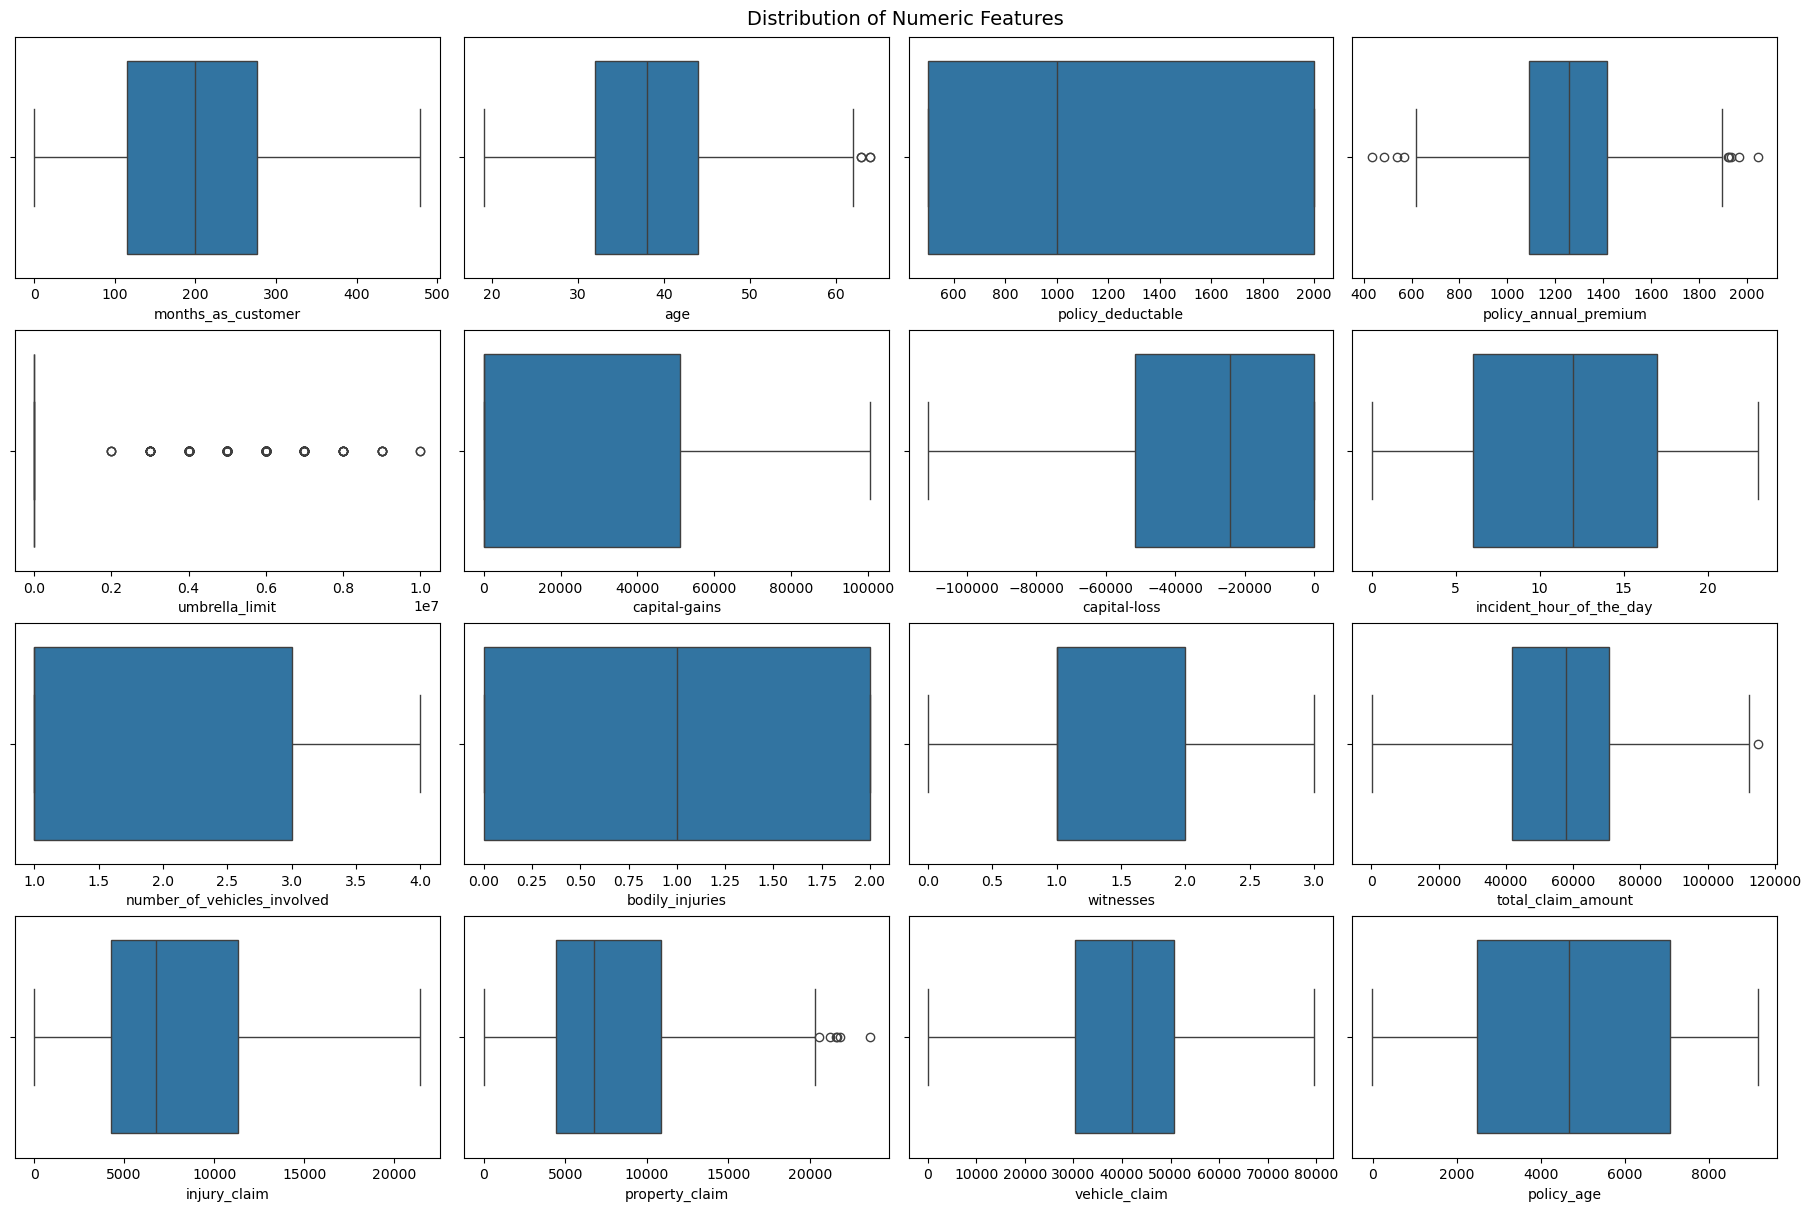

In [12]:
numeric = insurance_claims.select_dtypes(include = ['int64', 'float64'])

fig, axes = plt.subplots(4, 4, figsize = (18, 12), constrained_layout = True)
axes = axes.flatten()
plt.suptitle('Distribution of Numeric Features', fontsize = 14)

for i in range(len(numeric.columns)):
    sns.boxplot(x = numeric[numeric.columns[i]], ax = axes[i])

plt.show()

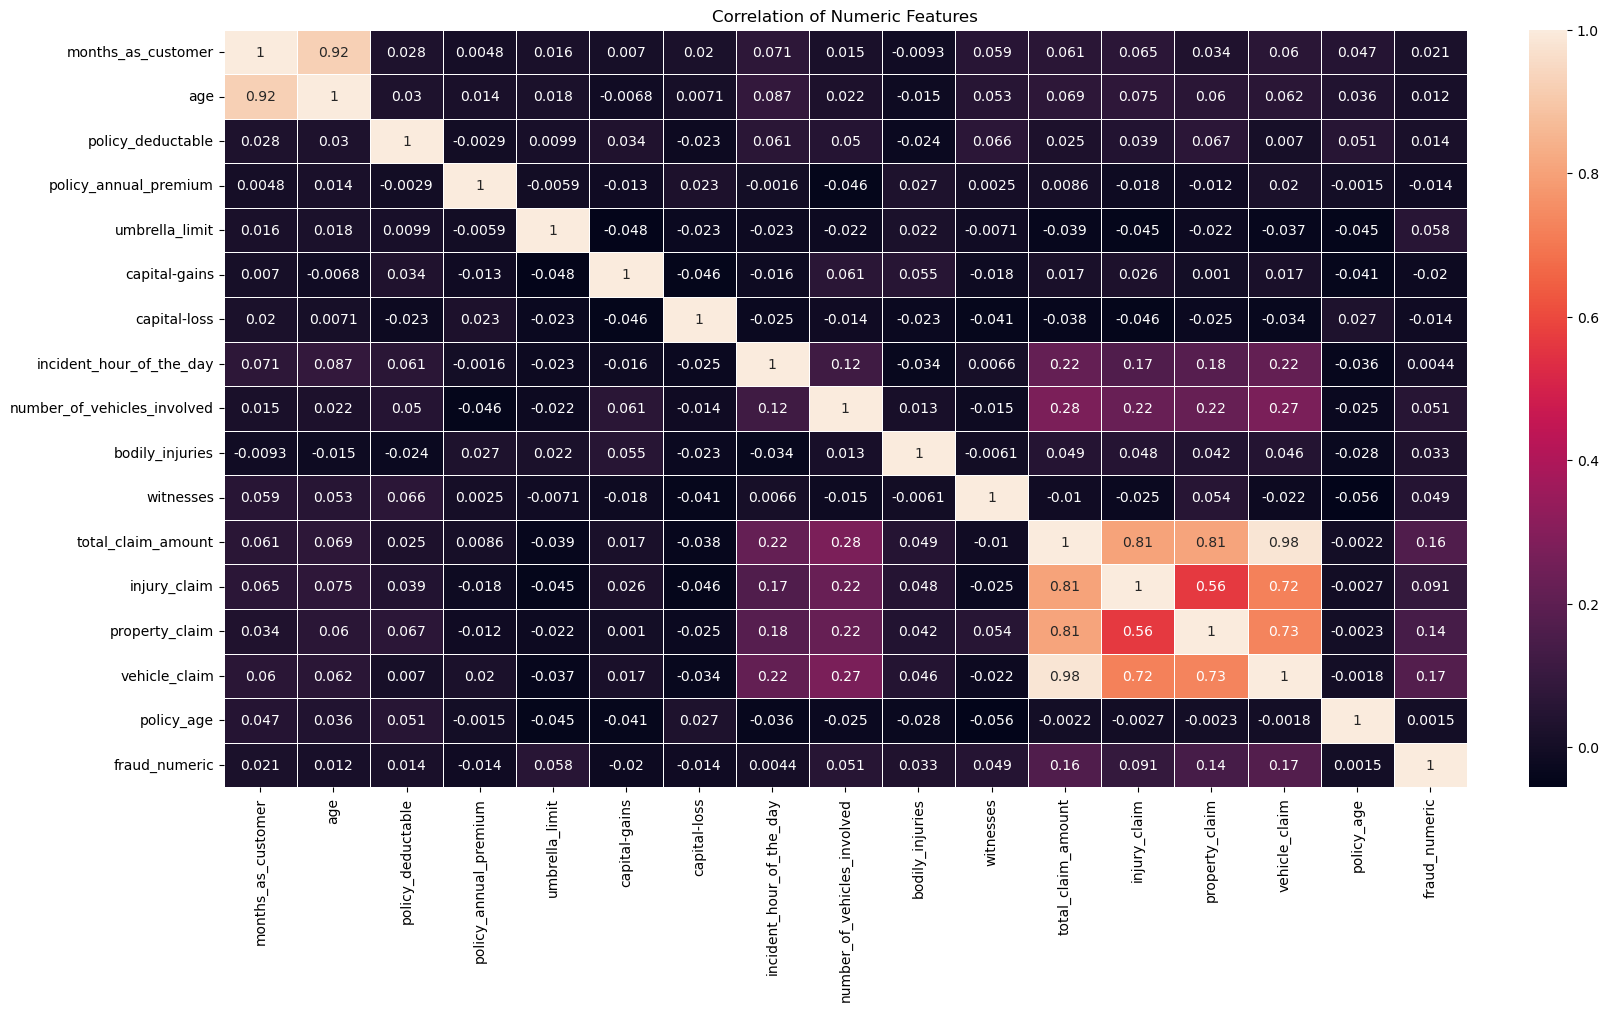

In [13]:
numeric['fraud_numeric'] = insurance_claims['fraud_reported'].map({'N': 0, 'Y': 1})

numeric_corr = numeric.corr()

plt.figure(figsize = (16, 10), constrained_layout = True)

sns.heatmap(numeric_corr, annot = True, fmt = '.2g', linewidths = 0.5)
plt.title('Correlation of Numeric Features')

plt.show()

In [14]:
numeric = numeric.drop(columns = ['months_as_customer', 'total_claim_amount', 'fraud_numeric'])

In [15]:
t_test_scores = {}

for col in numeric:
    fraud_column = insurance_claims[insurance_claims['fraud_reported'] == 'Y'][col]
    nonfraud_column = insurance_claims[insurance_claims['fraud_reported'] == 'N'][col]

    t_stat, p_value = stats.ttest_ind(fraud_column, nonfraud_column, equal_var = False)
    t_test_scores[col] = (t_stat, p_value, p_value < 0.05)

t_test_scores_df = pd.DataFrame.from_dict(t_test_scores, orient = 'index', columns = ['t_stat', 'p_value', 'significant'])
t_test_scores_df

,t_stat,p_value,significant
age,0.375679,7.073569e-01,False
policy_deductable,0.441593,6.590182e-01,False
policy_annual_premium,-0.440425,6.598652e-01,False
umbrella_limit,1.735658,8.342898e-02,False
capital-gains,-0.623945,5.330016e-01,False
capital-loss,-0.457967,6.472087e-01,False
incident_hour_of_the_day,0.140783,8.881086e-01,False
number_of_vehicles_involved,1.594119,1.116869e-01,False
bodily_injuries,1.040387,2.987680e-01,False
witnesses,1.599531,1.104217e-01,False


## Categorical Features

Across the categorical columns, cases of fraud and no-fraud seem to be evenly distributed, roughly $25\%:75\%$. The column `incident_severity` reveals that `Major Damage` claims show a higher proportion of fraud compared to non-fraud, making it the only sub-category where fraud dominates. This suggests that the more serious the accident is, the more likely fraud has taken place. Other columns, such as `incident_type`, further reveal that most fraud takes place during vehicle collisions.

According to the Chi-square tests, the features: `incident_type`, `collision_type`, `incident_severity`, `authorities_contacted`, and `property_damage`, show a statistically significant association with fraud under $\alpha = 0.05$. `incident_severity` has overwhelmingly strong evidence of significance, which lines up with the bar chart, while the other columns are significant but weaker. The other features do not show a clear difference in the fraud distribution but may contribute to classification when paired with another feature.

In [16]:
categorical = insurance_claims.select_dtypes(include = ['object'])

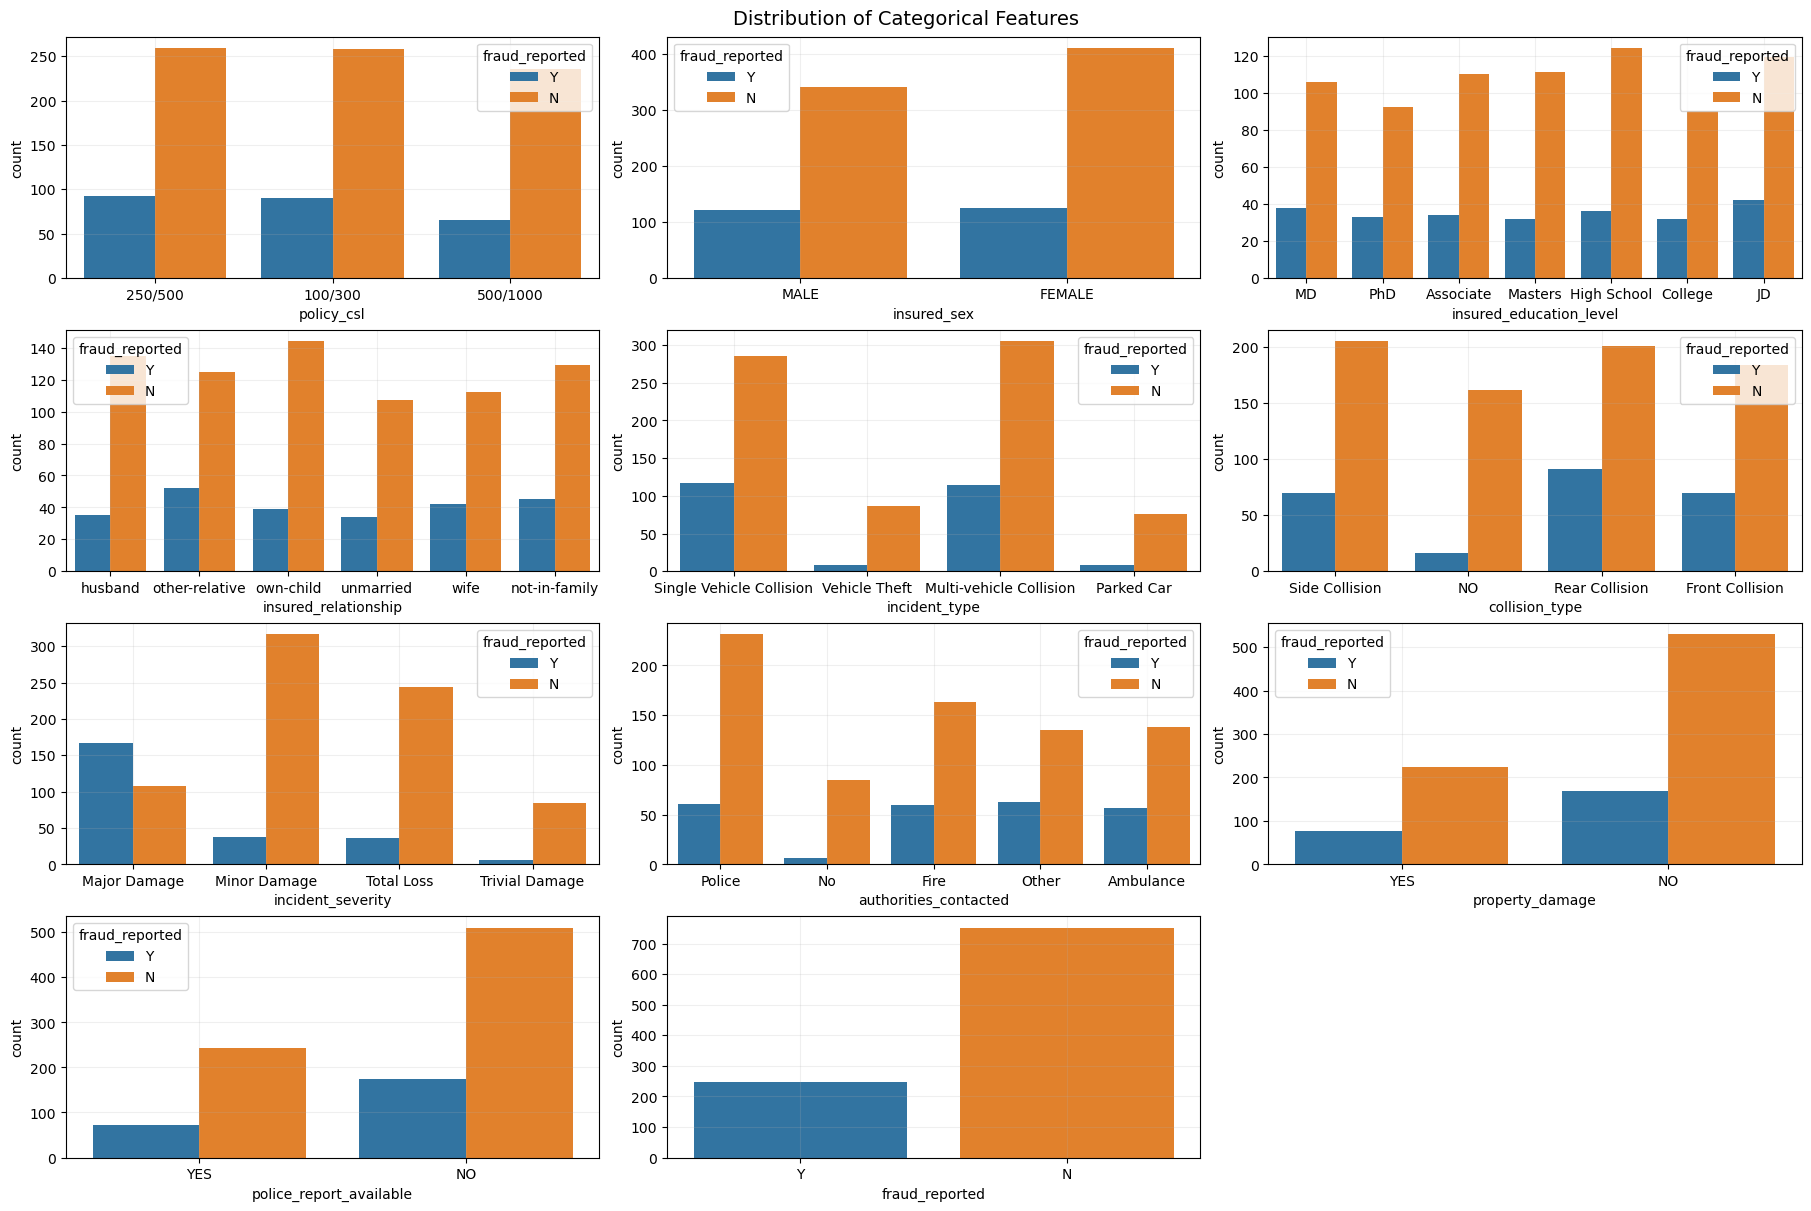

In [17]:
fig, axes = plt.subplots(4, 3, figsize = (18, 12), constrained_layout = True)
axes = axes.flatten()
plt.suptitle('Distribution of Categorical Features', fontsize = 14)

for i in range(len(categorical.columns)):
    sns.countplot(x = categorical[categorical.columns[i]], data = categorical, ax = axes[i], hue = categorical['fraud_reported'])
    axes[i].grid(alpha = 0.2)

axes[11].set_visible(False)

plt.show()

In [18]:
categorical.head()

,policy_csl,insured_sex,insured_education_level,insured_relationship,incident_type,collision_type,incident_severity,authorities_contacted,property_damage,police_report_available,fraud_reported
0,250/500,MALE,MD,husband,Single Vehicle Collision,Side Collision,Major Damage,Police,YES,YES,Y
1,250/500,MALE,MD,other-relative,Vehicle Theft,NO,Minor Damage,Police,NO,NO,Y
2,100/300,FEMALE,PhD,own-child,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NO,NO,N
3,250/500,FEMALE,PhD,unmarried,Single Vehicle Collision,Front Collision,Major Damage,Police,NO,NO,Y
4,500/1000,MALE,Associate,unmarried,Vehicle Theft,NO,Minor Damage,No,NO,NO,N


In [19]:
chi_scores = {}

for col in categorical:
    if col == 'fraud_reported':
        continue
        
    contigency_table = pd.crosstab(categorical[col], categorical['fraud_reported'])
    chi_results = stats.chi2_contingency(contigency_table)
    chi_scores[col] = (chi_results.statistic, chi_results.pvalue, chi_results.pvalue < 0.05)

chi_scores_df = pd.DataFrame.from_dict(chi_scores, orient = 'index', columns = ['chi_stat', 'p_value', 'significant'])
chi_scores_df

,chi_stat,p_value,significant
policy_csl,2.165775,3.386164e-01,False
insured_sex,0.851032,3.562605e-01,False
insured_education_level,1.656434,9.484348e-01,False
insured_relationship,5.454564,3.629538e-01,False
incident_type,29.237839,1.995970e-06,True
collision_type,31.363452,7.126946e-07,True
incident_severity,265.705961,2.620896e-57,True
authorities_contacted,26.430691,2.590632e-05,True
property_damage,0.242136,6.226673e-01,False
police_report_available,0.658188,4.172004e-01,False


# Modelling

The columns that cannot be represented through binary such as `insured_sex` have been turned into one-hot encodings. For a column like `insured_education_level`, it may be possible to create a hierarchical encoding, where the higher the education level the higher the assigned value. 

In [20]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoding = ['policy_csl', 'insured_education_level', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 
                    'authorities_contacted']
binary_encoding = ['insured_sex', 'property_damage', 'police_report_available', 'fraud_reported']

categorical['insured_sex'] = categorical['insured_sex'].map({'FEMALE': 0, 'MALE': 1})
categorical['property_damage'] = categorical['property_damage'].map({'NO': 0, 'YES': 1})
categorical['police_report_available'] = categorical['police_report_available'].map({'NO': 0, 'YES': 1})
categorical['fraud_reported'] = categorical['fraud_reported'].map({'N': 0, 'Y': 1})

encoder = OneHotEncoder(sparse_output = False).set_output(transform = 'pandas')
one_hot = encoder.fit_transform(categorical[one_hot_encoding])
categorical = pd.concat([categorical.drop(columns = one_hot_encoding), one_hot], axis = 1)

In [21]:
numeric_columns = numeric.columns
fraud_model_data = pd.concat([categorical, numeric], axis = 1)
fraud_model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   insured_sex                             999 non-null    int64  
 1   property_damage                         999 non-null    int64  
 2   police_report_available                 999 non-null    int64  
 3   fraud_reported                          999 non-null    int64  
 4   policy_csl_100/300                      999 non-null    float64
 5   policy_csl_250/500                      999 non-null    float64
 6   policy_csl_500/1000                     999 non-null    float64
 7   insured_education_level_Associate       999 non-null    float64
 8   insured_education_level_College         999 non-null    float64
 9   insured_education_level_High School     999 non-null    float64
 10  insured_education_level_JD              999 non-null    float64
 11

In [22]:
from sklearn.model_selection import train_test_split

x = fraud_model_data.drop(columns = ['fraud_reported'])
y = fraud_model_data['fraud_reported']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)
all_columns = x_train.columns

## Logistic Regression

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers = [
        ('numeric_scaled', StandardScaler(), numeric_columns)
    ], 
    remainder = 'passthrough'
)

lr = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter = 1000))
    ]
)

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, roc_curve

lr.fit(x_train, y_train)

def classification_results(model, x_train = x_train, y_train = y_train, x_test = x_test, y_test = y_test, report = False):
    y_train_prediction = model.predict(x_train)

    print('TRAINING METRICS')
    print(f'Accuracy: {accuracy_score(y_train, y_train_prediction):.4f}')
    print('Confusion Matrix: \n', confusion_matrix(y_train, y_train_prediction))
    if report:
        print('Classification Report: \n', classification_report(y_train, y_train_prediction))
    
    y_test_prediction = model.predict(x_test)
    y_test_probability = model.predict_proba(x_test)[:, 1]

    results = {
        'accuracy': accuracy_score(y_test, y_test_prediction),
        'roc_auc': roc_curve(y_test, y_test_probability),
        'confusion_matrix': confusion_matrix(y_test, y_test_prediction),
        'classification_report': classification_report(y_test, y_test_prediction, output_dict = True),
        'y_pred': y_test_prediction,
        'y_prob': y_test_probability
    }

    print('TESTING METRICS')
    print(f'Accuracy: {results['accuracy']:.4f}')
    print('Confusion Matrix: \n', results['confusion_matrix'])
    if report:
        print('Classification Report: \n', classification_report(y_test, y_test_prediction))

    return results

_ = classification_results(lr)

TRAINING METRICS
Accuracy: 0.8160
Confusion Matrix: 
 [[547  54]
 [ 93 105]]
TESTING METRICS
Accuracy: 0.8400
Confusion Matrix: 
 [[138  13]
 [ 19  30]]


In [25]:
from sklearn.model_selection import TunedThresholdClassifierCV

lr_threshold = TunedThresholdClassifierCV(estimator = lr, scoring = 'balanced_accuracy', cv = 5, random_state = 42, store_cv_results = True)

lr_threshold.fit(x_train, y_train)

print(f'Threshold: {lr_threshold.best_threshold_:.4f} \n')

lr_results = classification_results(lr_threshold, report = True)

Threshold: 0.2863 

TRAINING METRICS
Accuracy: 0.8048
Confusion Matrix: 
 [[509  92]
 [ 64 134]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       601
           1       0.59      0.68      0.63       198

    accuracy                           0.80       799
   macro avg       0.74      0.76      0.75       799
weighted avg       0.82      0.80      0.81       799

TESTING METRICS
Accuracy: 0.8200
Confusion Matrix: 
 [[128  23]
 [ 13  36]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.85      0.88       151
           1       0.61      0.73      0.67        49

    accuracy                           0.82       200
   macro avg       0.76      0.79      0.77       200
weighted avg       0.83      0.82      0.83       200



## Random Forest Classifier

In [26]:
from sklearn.ensemble import RandomForestClassifier

rfc = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(class_weight = 'balanced'))
    ]
)

In [27]:
rfc.fit(x_train, y_train)

_ = classification_results(rfc)

TRAINING METRICS
Accuracy: 1.0000
Confusion Matrix: 
 [[601   0]
 [  0 198]]
TESTING METRICS
Accuracy: 0.8100
Confusion Matrix: 
 [[140  11]
 [ 27  22]]


In [48]:
from sklearn.model_selection import RandomizedSearchCV

parameters = {
    'model__n_estimators': [25, 50, 100], 
    'model__criterion': ['gini', 'entropy'],
    'model__min_samples_split': [2, 3, 5],
    'model__min_samples_leaf': [1, 2, 4], 
    'model__max_depth': [3, 4, 5]
}

rfc_rs = RandomizedSearchCV(rfc, parameters, n_iter = 50, cv = 5, scoring = 'recall', random_state = 42, n_jobs = -1)
rfc_rs.fit(x_train, y_train)
best_rfc = rfc_rs.best_estimator_

print('Best Parameters:', rfc_rs.best_params_, '\n')

_ = classification_results(best_rfc)

Best Parameters: {'model__n_estimators': 25, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 3, 'model__criterion': 'gini'} 

TRAINING METRICS
Accuracy: 0.8123
Confusion Matrix: 
 [[508  93]
 [ 57 141]]
TESTING METRICS
Accuracy: 0.8300
Confusion Matrix: 
 [[130  21]
 [ 13  36]]


In [49]:
rfc_threshold = TunedThresholdClassifierCV(estimator = best_rfc, scoring = 'balanced_accuracy', cv = 5, random_state = 42, 
                                           store_cv_results = True)

rfc_threshold.fit(x_train, y_train)

print(f'Threshold: {rfc_threshold.best_threshold_:.4f} \n')

rfc_results = classification_results(rfc_threshold, report = True)

Threshold: 0.4815 

TRAINING METRICS
Accuracy: 0.8060
Confusion Matrix: 
 [[513  88]
 [ 67 131]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.85      0.87       601
           1       0.60      0.66      0.63       198

    accuracy                           0.81       799
   macro avg       0.74      0.76      0.75       799
weighted avg       0.81      0.81      0.81       799

TESTING METRICS
Accuracy: 0.8350
Confusion Matrix: 
 [[131  20]
 [ 13  36]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.87      0.89       151
           1       0.64      0.73      0.69        49

    accuracy                           0.83       200
   macro avg       0.78      0.80      0.79       200
weighted avg       0.84      0.83      0.84       200



## Gradient Boosting Classifier

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier())
    ]
)

In [31]:
gbc.fit(x_train, y_train)

_ = classification_results(gbc)

TRAINING METRICS
Accuracy: 0.9262
Confusion Matrix: 
 [[589  12]
 [ 47 151]]
TESTING METRICS
Accuracy: 0.7900
Confusion Matrix: 
 [[137  14]
 [ 28  21]]


In [47]:
parameters = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [50, 100, 150], 
    'model__max_depth': [3, 4, 5],
    'model__min_samples_split': [2, 3, 5],
    'model__min_samples_leaf': [1, 2, 4]
}

gbc_rs = RandomizedSearchCV(gbc, parameters, n_iter = 100, cv = 5, scoring = 'recall', random_state = 42, n_jobs = -1)
gbc_rs.fit(x_train, y_train)
best_gbc = gbc_rs.best_estimator_

print('Best Parameters:', gbc_rs.best_params_, '\n')

_ = classification_results(best_gbc)

Best Parameters: {'model__n_estimators': 50, 'model__min_samples_split': 3, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.05} 

TRAINING METRICS
Accuracy: 0.8698
Confusion Matrix: 
 [[570  31]
 [ 73 125]]
TESTING METRICS
Accuracy: 0.7950
Confusion Matrix: 
 [[135  16]
 [ 25  24]]


In [46]:
gbc_threshold = TunedThresholdClassifierCV(estimator = best_gbc, scoring = 'balanced_accuracy', cv = 5, random_state = 42, store_cv_results = True)

gbc_threshold.fit(x_train, y_train)

print(f'Threshold: {gbc_threshold.best_threshold_:.4f} \n')

gbc_results = classification_results(gbc_threshold, report = True)

Threshold: 0.2822 

TRAINING METRICS
Accuracy: 0.8223
Confusion Matrix: 
 [[513  88]
 [ 54 144]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.90      0.85      0.88       601
           1       0.62      0.73      0.67       198

    accuracy                           0.82       799
   macro avg       0.76      0.79      0.77       799
weighted avg       0.83      0.82      0.83       799

TESTING METRICS
Accuracy: 0.8100
Confusion Matrix: 
 [[126  25]
 [ 13  36]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.83      0.87       151
           1       0.59      0.73      0.65        49

    accuracy                           0.81       200
   macro avg       0.75      0.78      0.76       200
weighted avg       0.83      0.81      0.82       200



# Analysis

Looking at the accuracy comparison, the RFC model is the best, followed by LR and GBC. However, it should be noted that accuracy for tasks such as this should not be looked at alone, since high accuracy does not necessarily mean that the model can predict fraud.

The confusion matrices reveal more important data, suggesting all three models achieve the same performance in detecting fraud, correctly identifying 36 cases correctly and 13 cases incorrectly. However, there is a discrepancy in the number of false positives. RFC has the lowest at 20 compared to LR with 23 and GBC with 25. This indicates that RF provides a better balance, reducing the number of non-fraud cases incorrectly flagged as fraud. Although this is not as important as detecting fraud, it is still valuable to reduce the false positive, as it will lead to fewer unnecessary investigations and operational costs. 

Looking at more detail, the classification report shows that although the recall for the fraud class is the same across models, the precision is not. This distinction is very important, as it reveals that the predictions are not equally reliable. RFC achieves a precision of around 0.05 higher than the other models, meaning that when a transaction is fraudulent, RFC is more confident about its prediction. Across the F1-Score, RFC is the clear strongest model with the highest score over fraud and non-fraud cases. 

The ROC curve measures how the model distinguishes between fraud and non-fraud at each threshold. LR achieves the highest AUC at 0.82, indicating that it ranks fraudulent cases higher than non-fraudulent cases. However, when the threshold is tuned, RFC performs better in practice with a lower false positive rate and higher precision. 

The insights from the feature importance reveal that `capital_loss` is by far the most important predictor in each model. The features after that do not seem to be very similar. The best model, RFC, presents the education levels as relatively important with other features of some importance after that. What is interesting is that no model suggests that the `vehicle_claim` is in the top 10 most important features, although it was the strongest statistically significant numerical feature. Similarly, `incident_severity` was overwhelmingly significant but only appears to be partially important in the LR model, as `trivial_damage` is the fourth most important feature. This is fascinating, as the `incident_severity` distributions show that `trivial_damage` occurs in nearly no reported fraud cases. 

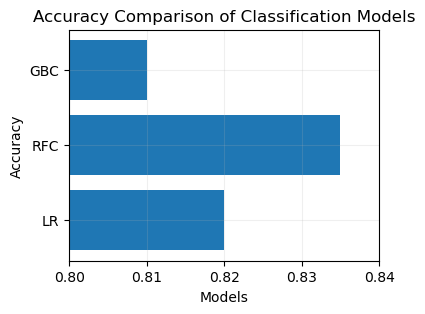

In [50]:
model_accuracy = {'LR': lr_results['accuracy'],
                  'RFC': rfc_results['accuracy'],
                  'GBC': gbc_results['accuracy']}

plt.figure(figsize = (4, 3))

plt.barh(model_accuracy.keys(), model_accuracy.values())
plt.title('Accuracy Comparison of Classification Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.grid(alpha = 0.2)
plt.xlim(0.8, 0.84)

plt.show()

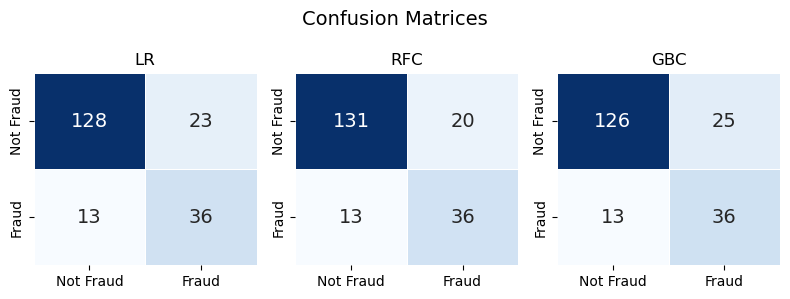

In [52]:
confusion_matrices = {'LR': lr_results['confusion_matrix'],
                      'RFC': rfc_results['confusion_matrix'],
                      'GBC': gbc_results['confusion_matrix']}

fig, axes = plt.subplots(1, 3, figsize = (8, 3))
plt.suptitle('Confusion Matrices', fontsize = 14)
axes = axes.flatten()

for index, (model, matrix) in enumerate(confusion_matrices.items()):
    sns.heatmap(matrix, annot = True, linewidths = 0.5, ax = axes[index], cbar = False, xticklabels = ['Not Fraud', 'Fraud'], 
                yticklabels = ['Not Fraud', 'Fraud'], cmap = 'Blues', fmt = 'd', annot_kws = {"size": 14})
    axes[index].set_title(f'{model}')
    
plt.tight_layout()
plt.show()

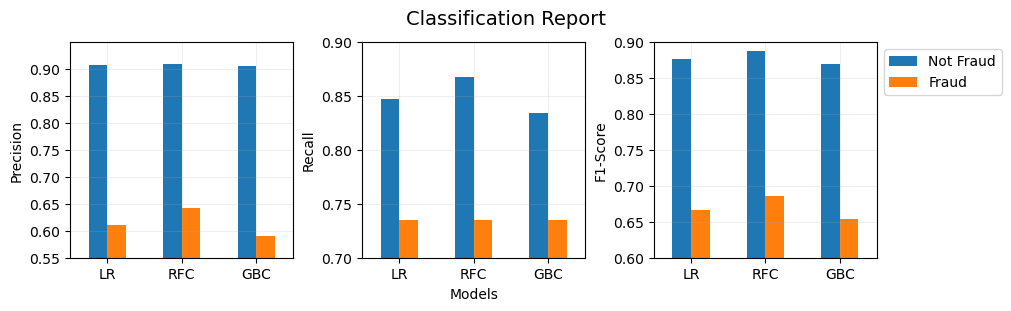

In [53]:
classification_reports = {'LR': lr_results['classification_report'],
                          'RFC': rfc_results['classification_report'],
                          'GBC': gbc_results['classification_report']}

precision_dict, recall_dict, f1_dict = {}, {}, {}

for model, report in classification_reports.items():
    precision_dict[model] = {'Not Fraud': report['0']['precision'],
                             'Fraud': report['1']['precision']}
    recall_dict[model] = {'Not Fraud': report['0']['recall'],
                          'Fraud': report['1']['recall']}
    f1_dict[model] = {'Not Fraud': report['0']['f1-score'],
                      'Fraud': report['1']['f1-score']}

precision_df = pd.DataFrame(precision_dict).T.reset_index()
recall_df = pd.DataFrame(recall_dict).T.reset_index()
f1_df = pd.DataFrame(f1_dict).T.reset_index()

fig, axes = plt.subplots(1, 3, figsize = (10, 3), constrained_layout = True)
plt.suptitle('Classification Report', fontsize = 14)

precision_df.plot(x = 'index', y = ['Not Fraud', 'Fraud'], kind = 'bar', ax = axes[0], legend = False, rot = 0)
recall_df.plot(x = 'index', y = ['Not Fraud', 'Fraud'], kind = 'bar', ax = axes[1], legend = False, rot = 0)
f1_df.plot(x = 'index', y = ['Not Fraud', 'Fraud'], kind = 'bar', ax = axes[2], legend = True, rot = 0)

settings = [('Precision', 0.55, 0.95), ('Recall', 0.7, 0.9), ('F1-Score', 0.6, 0.9)]

for i, values in enumerate(settings):
    axes[i].set_ylabel(values[0])
    axes[i].set_ylim(values[1], values[2])
    axes[i].set_yticks(np.arange(values[1], values[2], 0.05))
    axes[i].grid(alpha = 0.2)
    axes[i].set_xlabel('')

axes[1].set_xlabel('Models')

plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.show()

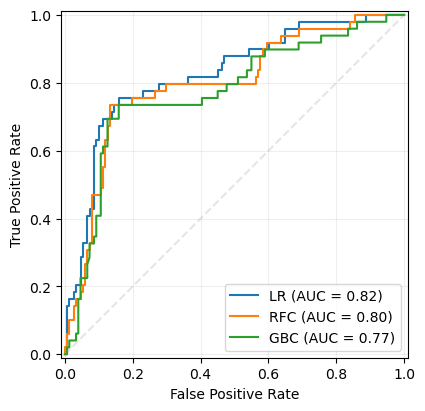

In [54]:
from sklearn.metrics import auc, RocCurveDisplay

roc_graph = {'LR': lr_results['roc_auc'],
             'RFC': rfc_results['roc_auc'],
             'GBC': gbc_results['roc_auc']}

fig, axes = plt.subplots(1, 1, figsize = (10, 4), constrained_layout = True)

for model, report in roc_graph.items():
    fpr, tpr = report[0], report[1]
    roc_auc = auc(fpr, tpr)
    display = RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc, name = model)
    display.plot(ax = axes)

plt.plot([0, 1], [0, 1], alpha = 0.2, color = 'gray', linestyle = '--')
plt.grid(alpha = 0.2)

plt.legend()
plt.show()

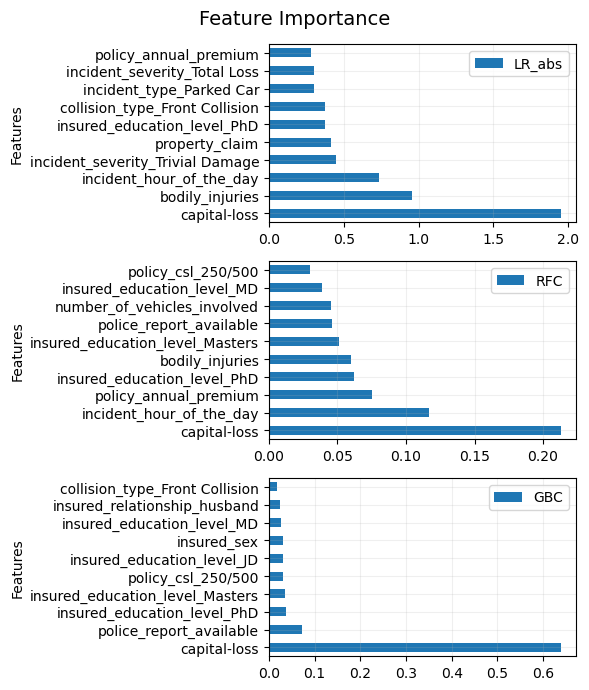

In [55]:
features_df = pd.DataFrame({'Features': x_train.columns, 
                            'LR': lr_threshold.estimator.named_steps['model'].coef_[0],
                            'RFC': best_rfc.named_steps['model'].feature_importances_,
                            'GBC': gbc_threshold.estimator.named_steps['model'].feature_importances_})

features_df['LR_abs'] = features_df['LR'].abs()

fig, axes = plt.subplots(3, 1, figsize = (6, 7))
axes = axes.flatten()
plt.suptitle('Feature Importance', fontsize = 14)

features_df.sort_values('LR_abs', ascending = False).head(10).plot(x = 'Features', y = 'LR_abs', kind = 'barh', ax = axes[0])
features_df.sort_values('RFC', ascending = False).head(10).plot(x = 'Features', y = 'RFC', kind = 'barh', ax = axes[1])
features_df.sort_values('GBC', ascending = False).head(10).plot(x = 'Features', y = 'GBC', kind = 'barh', ax = axes[2])

for i in range(3):
    axes[i].grid(alpha = 0.2)

plt.tight_layout()
plt.show()